# Chapter 21: The Bullwhip
Simulate inventory-position ordering, compare asymmetric inventory costs and
forecast intermittent demand. Data are synthetic and all policy rules explicit.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from scipy.stats import norm
rng=begin(21)

## Each echelon reacts to its immediate customer's orders
Inventory position equals net inventory plus pipeline. Backlogs are represented
as negative net inventory. Each order restores the forecast-based target.

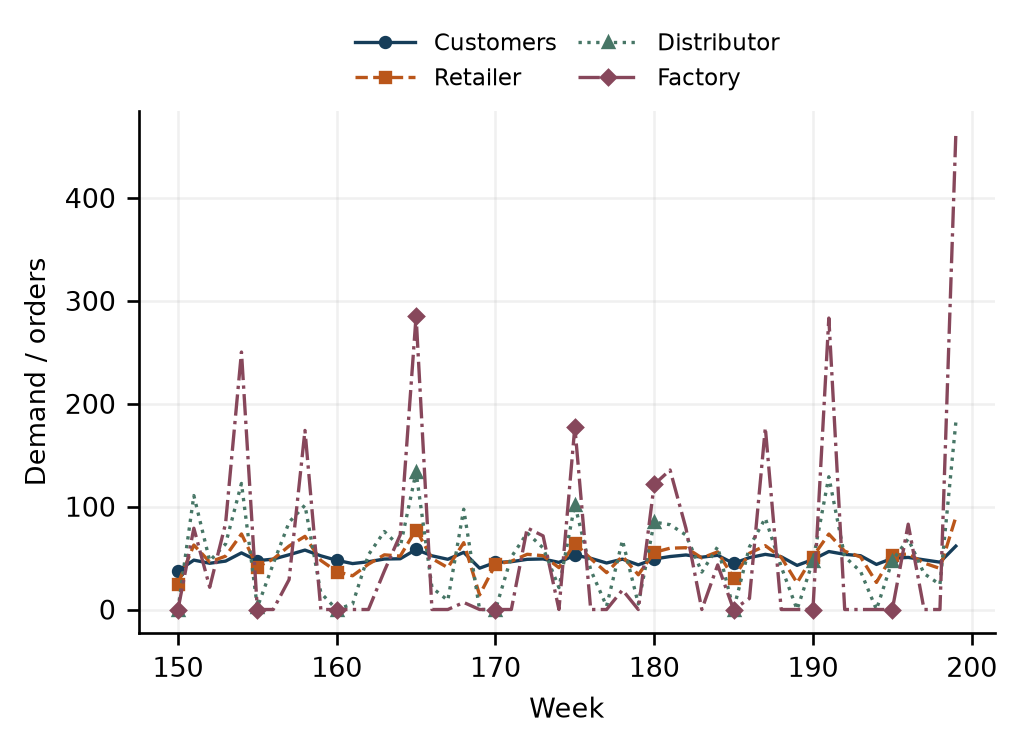

In [2]:
def echelon(demand,lead=3,alpha=.5):
    forecast=50.; net=200.; pipeline=[50.]*lead; orders=[]
    for d in demand:
        arrival=pipeline.pop(0); before=net; net+=arrival-d
        assert np.isclose(net,before+arrival-d)
        forecast=alpha*d+(1-alpha)*forecast
        target=(lead+1)*forecast+30
        order=max(0.,target-net-sum(pipeline)); pipeline.append(order); orders.append(order)
    return np.array(orders)
demand=np.maximum(0,50+rng.normal(0,5,250)); stages=[demand]
for _ in range(3): stages.append(echelon(stages[-1]))
plt.figure()
for name,values in zip(['Customers','Retailer','Distributor','Factory'],stages): plt.plot(np.arange(150,200),values[150:200],label=name,lw=.8)
plt.xlabel('Week'); plt.ylabel('Demand / orders'); plt.legend(fontsize=6)
save(21,1,'Local corrections become upstream volatility','Synthetic inventory-position policies with three-week lead times. Each stage forecasts its own incoming demand signal.','## Section One: Forrester at the Plant')

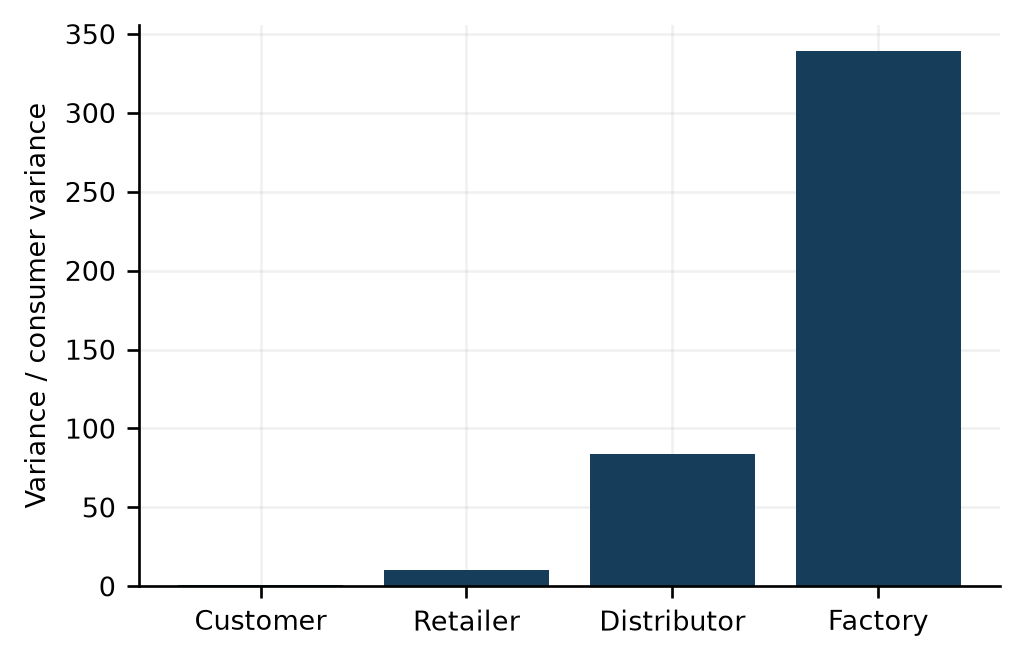

In [3]:
ratios=[np.var(s[50:])/np.var(demand[50:]) for s in stages]
plt.figure(); plt.bar(['Customer','Retailer','Distributor','Factory'],ratios); plt.ylabel('Variance / consumer variance')
save(21,2,'Measure amplification after warm-up','Variance ratios from the synthetic chain, excluding fifty initialization periods. Policy and delay choices determine the amplification.','## Section Three: When the Model Sees Noise as Signal')

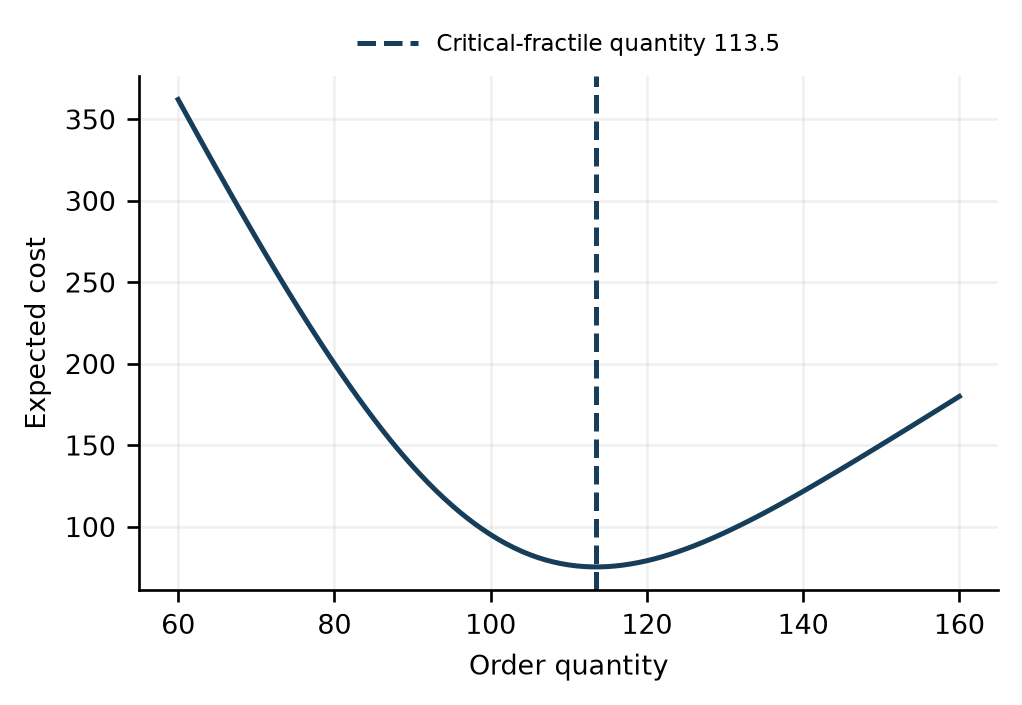

In [4]:
cu,co=9.,3.; samples=rng.normal(100,20,30000); quantities=np.arange(60,161)
cost=[np.mean(cu*np.maximum(samples-q,0)+co*np.maximum(q-samples,0)) for q in quantities]
opt=norm.ppf(cu/(cu+co),loc=100,scale=20)
plt.figure(); plt.plot(quantities,cost); plt.axvline(opt,ls='--',label=f'Critical-fractile quantity {opt:.1f}'); plt.xlabel('Order quantity'); plt.ylabel('Expected cost'); plt.legend(fontsize=7)
save(21,3,'The cheapest inventory level is not the mean','Synthetic normal demand with underage cost 9 and overage cost 3. The optimal demand CDF is cu/(cu+co), not the probability of selling an extra unit.','## Section Four: The Full Methodology')

## Intermittent demand separates occurrence from size
Croston updates size and interarrival interval only at demand events; TSB updates
occurrence probability every period, so it can respond to obsolescence.

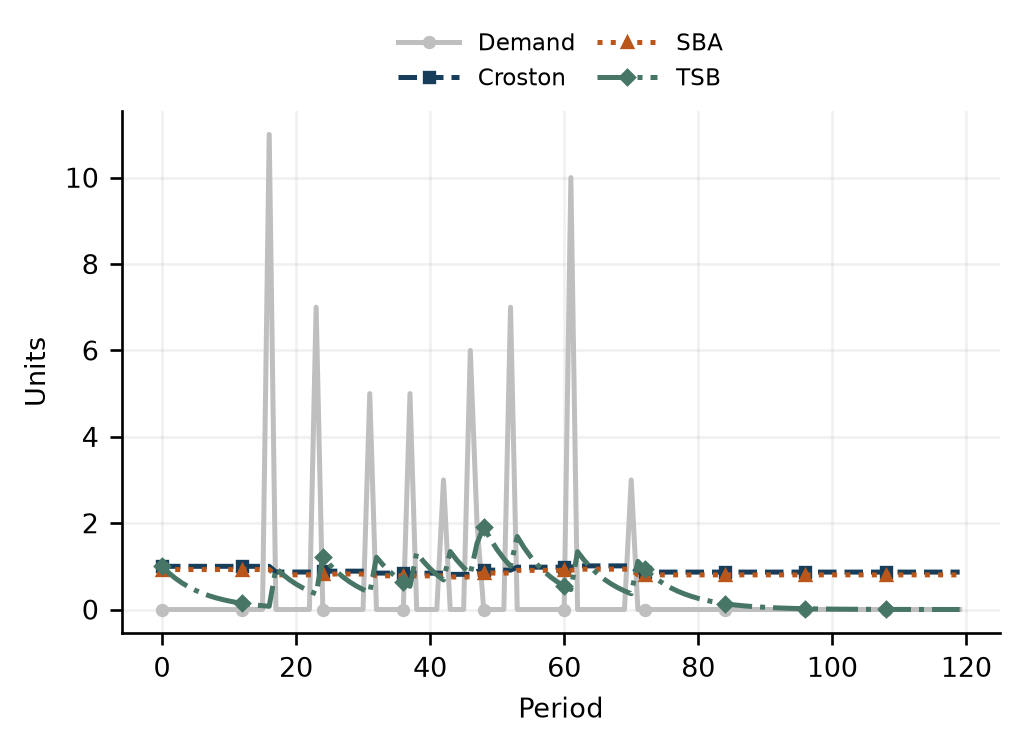

In [5]:
observed=np.where(rng.random(120)<.2,rng.poisson(5,120)+1,0); observed[80:]=0
alpha=.15; size=5.; interval=5.; prob=.2; gap=1; cro=[]; sba=[]; tsb=[]
for d in observed:
    cro.append(size/interval); sba.append((1-alpha/2)*size/interval); tsb.append(prob*size)
    prob=(1-alpha)*prob+alpha*(d>0)
    if d>0: size=(1-alpha)*size+alpha*d; interval=(1-alpha)*interval+alpha*gap; gap=1
    else: gap+=1
plt.figure(); plt.plot(observed,color='.75',label='Demand'); plt.plot(cro,label='Croston'); plt.plot(sba,label='SBA'); plt.plot(tsb,label='TSB'); plt.xlabel('Period'); plt.ylabel('Units'); plt.legend(fontsize=7)
save(21,4,'Obsolescence changes demand occurrence','Synthetic intermittent demand stops after period 80. Forecast lines are pre-update one-step estimates; TSB continues updating occurrence probability during zeros.','## Section Four: The Full Methodology')
assert tsb[-1]<tsb[80]

## Limits and exercise
Share consumer demand across stages and compare amplification. High ADI with low
CV-squared is intermittent; high values of both are lumpy; low ADI and high
CV-squared is erratic. Classification alone does not guarantee a winning method.

## Test information sharing on the same customer demand
The earlier chain forecasts each immediate customer's orders. Here every stage
observes consumer demand for its level estimate while still fulfilling orders
from the stage below. Lead times, starting inventory, safety stock and update
speed stay fixed. This isolates the information-policy change in this simulation.
It does not imply that sharing demand always removes physical capacity limits.

In [6]:
def informed_echelon(incoming,consumer_signal,lead=3,alpha=.5):
    forecast=50.; net=200.; pipeline=[50.]*lead; orders=[]
    for requested,signal in zip(incoming,consumer_signal):
        net+=pipeline.pop(0)-requested
        forecast=alpha*signal+(1-alpha)*forecast
        order=max(0.,(lead+1)*forecast+30-net-sum(pipeline))
        pipeline.append(order);orders.append(order)
    return np.asarray(orders)
shared_stages=[demand]
for _ in range(3): shared_stages.append(informed_echelon(shared_stages[-1],demand))
comparison=[]
for name,local,shared in zip(['Customer','Retailer','Distributor','Factory'],stages,shared_stages):
    comparison.append({'stage':name,'local_variance_ratio':float(np.var(local[50:])/np.var(demand[50:])),'shared_variance_ratio':float(np.var(shared[50:])/np.var(demand[50:]))})
print(comparison)
assert np.array_equal(shared_stages[0],stages[0])
print('Interpretation: compare upstream variance after the same warm-up. The result belongs to these inventory policies and lead times; sharing a signal is not changing the underlying customer demand.')

[{'stage': 'Customer', 'local_variance_ratio': 1.0, 'shared_variance_ratio': 1.0}, {'stage': 'Retailer', 'local_variance_ratio': 10.141614140394308, 'shared_variance_ratio': 10.141614140394308}, {'stage': 'Distributor', 'local_variance_ratio': 83.71885178353389, 'shared_variance_ratio': 28.7109459960515}, {'stage': 'Factory', 'local_variance_ratio': 339.032406735193, 'shared_variance_ratio': 52.703311822049905}]
Interpretation: compare upstream variance after the same warm-up. The result belongs to these inventory policies and lead times; sharing a signal is not changing the underlying customer demand.


<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below connect the controlled figures to a complete applied input/output workflow.

# Chapter 21 workshop: from lesson to decision

## Explain the mechanism

Forecasts and replenishment decisions form a feedback system. Upstream orders include inventory corrections and may amplify consumer variation. For intermittent demand, occurrence and size carry different information; prolonged zeros need not be treated like small positive demand.

## Work through the arithmetic

With positive-demand estimate 5 and interval estimate 4, Croston predicts 1.25 units per period. At alpha=.2, SBA gives (1-.1)×1.25=1.125. TSB with occurrence probability .25 predicts 1.25; after a zero at alpha=.2, probability becomes .2 and the next forecast is 1.0. For underage 9 and overage 3, the optimal single-period CDF quantile is .75.

Treat this hand calculation as a mechanism check. Compare its units and assumptions with the business target before using the executable adapter below.

## Adapt the lesson to reader data

Replace observed in the intermittent block with a complete nonnegative demand calendar. Replace demand in the chain block only after setting realistic inventory and lead times. The original lesson’s shared-information comparison is an exercise; add and verify that policy explicitly before reporting improvement.

Keep the controlled example as a reproducible teaching case. Work in a copy when replacing its data; retain raw input, a cleaned table and an explanation of exclusions. Real data need a named source, extraction date, usable-as-of date and units. If an actual is revised later, preserve the vintage available when the forecast would have been issued. Never silently label synthetic generator output as an external dataset.

For this chapter, settle these questions before fitting: Are zeros true zero demand or stockouts? What lead time and review cadence apply? Are backlogs allowed? What underage/overage costs matter? Is end-customer demand visible upstream?

## Interpret the actual lesson outputs

The chain conserves net inventory including backlogs and reports variance after warm-up. The stocking curve uses a known synthetic normal demand distribution. Intermittent forecasts are recorded before each observation update, so their response to the eventual all-zero regime can be evaluated without hindsight.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,actual,Croston,SBA,TSB,order_up_to,cost_optimal_order_up_to,on_hand,backlog,order`.
- `summary.json`: `mae,lead_time,review_period,service_level,achieved_cycle_service,fill_rate,mean_on_hand,mean_backlog,mean_cost,bullwhip,training_quantile_order` plus method, interpretation, assumptions, not_done and status.

The tool produces pre-update Croston, SBA and TSB one-step forecasts and their MAE over the test period, then simulates an order-up-to policy: at each review it bootstraps `samples` sums of `lead_time + review_period` draws from the trailing `bootstrap_window` demands, sets the order-up-to level at the `service_level` quantile (the cost-optimal quantile is reported beside it), receives pipeline arrivals, serves backlog then demand, and records on-hand, backlog and orders, yielding achieved cycle service, fill rate, mean on-hand, mean backlog and mean cost. It also runs an `echelons`-deep bullwhip simulation on the same demand, reporting variance amplification per echelon with local ordering and with a shared end-consumer signal. Lead time is fixed; demand is treated as uncensored. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

The [fixture](../data/examples/ch21.csv) and [config](../configs/ch21.json) match the current interface. Run the `apply` command in the [skill entrypoint](../../forecasting-skills/forecasting-ch21-supply-chain/SKILL.md), using a new empty output folder. Any broader methodology in this workshop requires separately recorded evidence or an explicit extension; successful command execution does not imply those steps happened.

## Decide what the evidence supports

TSB updates occurrence probability even during zeros; Croston updates at positive events and can remain elevated after obsolescence. Demand classification is descriptive, not model selection. A bullwhip variance ratio depends on policy and initialization; exclude a justified warm-up.

If stockouts hide demand, forecast observed sales only or use a separately supported censoring method. Without costs, report service/quantity scenarios rather than one optimal order. Without pipeline information, the full policy is a scenario, not a reconstructed operation.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,actual,Croston,SBA,TSB,order_up_to,cost_optimal_order_up_to,on_hand,backlog,order`; `summary.json` keys: `mae,lead_time,review_period,service_level,achieved_cycle_service,fill_rate,mean_on_hand,mean_backlog,mean_cost,bullwhip,training_quantile_order` plus method, interpretation, assumptions, not_done and status. Report achieved cycle service and fill rate together with the target; a policy that hits 95 percent cycle service with a 60 percent fill rate is a different promise to the customer.

## Three exercises with worked solutions

### Exercise 1

Underage cost 4, overage cost 6: target quantile?

**Worked solution.** 4/(4+6)=.4.

### Exercise 2

A zero record occurs because shelves were empty. Is it a true no-demand event for TSB?

**Worked solution.** Not established. It is censored sales; treating it as no demand can suppress forecasts incorrectly.

### Exercise 3

Consumer variance 25 and order variance 100: amplification ratio?

**Worked solution.** 100/25=4, provided periods and warm-up treatment match.

## Business-reader application

Use this request with the skill:

> Use chapter 21 to forecast intermittent demand.csv, distinguish zeros from stockouts and connect supported forecasts to explicit lead-time and inventory-cost assumptions.

Read the returned result as a decision record. Check that the forecast answers your unit and horizon, that its comparison uses information available at the time, and that any recommendation follows from the stated loss or business objective. Ask which missing measurement would most change the conclusion.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

## Configure and run the applied case

The input file and JSON below are the only entry-point changes needed to try another
case with the same schema. Keep the original examples for comparison. Supply source
and units in the configuration; resolve missing periods rather than silently filling
unknown observations with zeros. These calculations call the same tested functions
as the `run.py apply` command. A failed validation is a reason to inspect the data,
not to replace it with invented observations.

The default input here is a **seeded synthetic schema example**, separate from any
observed-data application below. Read the summary before interpreting its results.

In [7]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json
import pandas as pd
import json, os
INPUT_PATH = project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists()) / 'companion/data/examples/ch21.csv'
CONFIG_PATH = project_path.parents[2] / 'configs/ch21.json'
# Input paths are explicit and may be replaced with reader-supplied files.
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(21, workshop_input, workshop_config)
print(json.dumps(clean_json(workshop_summary), indent=2))
print(workshop_table.head(12).to_string(index=False))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', CONFIG_PATH.parents[1])) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch21-workshop-results.csv', index=False)
(workshop_output/'ch21-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

{
  "method": "Intermittent-demand forecasts, bootstrapped order-up-to policy simulation, N-echelon bullwhip",
  "interpretation": "Intermittent forecasts MAE: Croston 5.62, SBA 6.23, TSB 5.62. Order-up-to policy at 95% target over a 3-period protection window: cycle service 100%, fill rate 100%, mean on-hand 61.5, mean backlog 0. Bullwhip variance ratios by echelon, local [4.01, 18.3, 72.45] vs shared signal [4.01, 10.11, 19.3].",
  "assumptions": [
    "Lead time 2, review period 1",
    "Demand during protection window bootstrapped from the trailing window",
    "Unmet demand is backordered, not lost"
  ],
  "not_done": [
    "Lead time treated as fixed; no supplier variability or capacity limits",
    "Demand treated as uncensored sales; stockouts in history are not corrected",
    "Costs are per period on-hand and backlog only"
  ],
  "status": "passed",
  "mae": {
    "Croston": 5.621972528617353,
    "SBA": 6.23002183629881,
    "TSB": 5.621922257881865
  },
  "lead_time": 2,
  

1509

## Real-data boundary

The bundled case is controlled, not a reconstruction of historical records. No
verified, appropriately licensed domain dataset is supplied for this particular
workflow. Use the input contract to supply your own observations and evidence.
Do not substitute an unrelated public dataset simply to call the example real.
The wider companion includes observed time-series applications in chapters
3–6, 12, 15–16 and 24; their data do not establish this chapter’s domain assumptions.

## Read the result as a decision record

Start with the summary’s **interpretation**, then examine its numerical evidence.
Distinguish what was fitted, what was supplied, and what remains unidentified.
The results table is the calculation; it is not permission to act. Explain which
assumption would most change the answer and what new evidence would test it.
For a live forecast, set an outcome date and keep the original result for scoring.

The exercises and worked solutions above test interpretation, calculation, and
adaptation. Re-run a changed assumption and compare the actual output; do not
reuse numbers from the book when your input or horizon changes.